# Figures for VLBA Proposal

SED and radio light curve of SN 2018ivc, marking the requested VLBA U-band frequency coverage and observation phases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

from matplotlib.colors import LogNorm
import functions
from scipy.interpolate import make_interp_spline
from scipy.interpolate import PchipInterpolator

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

# --- Load data ---
data = pd.read_csv("data/radio_18ivc_data.csv")

# --- Style ---
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


## Figure 1: Late-Time SED with VLBA X-band coverage

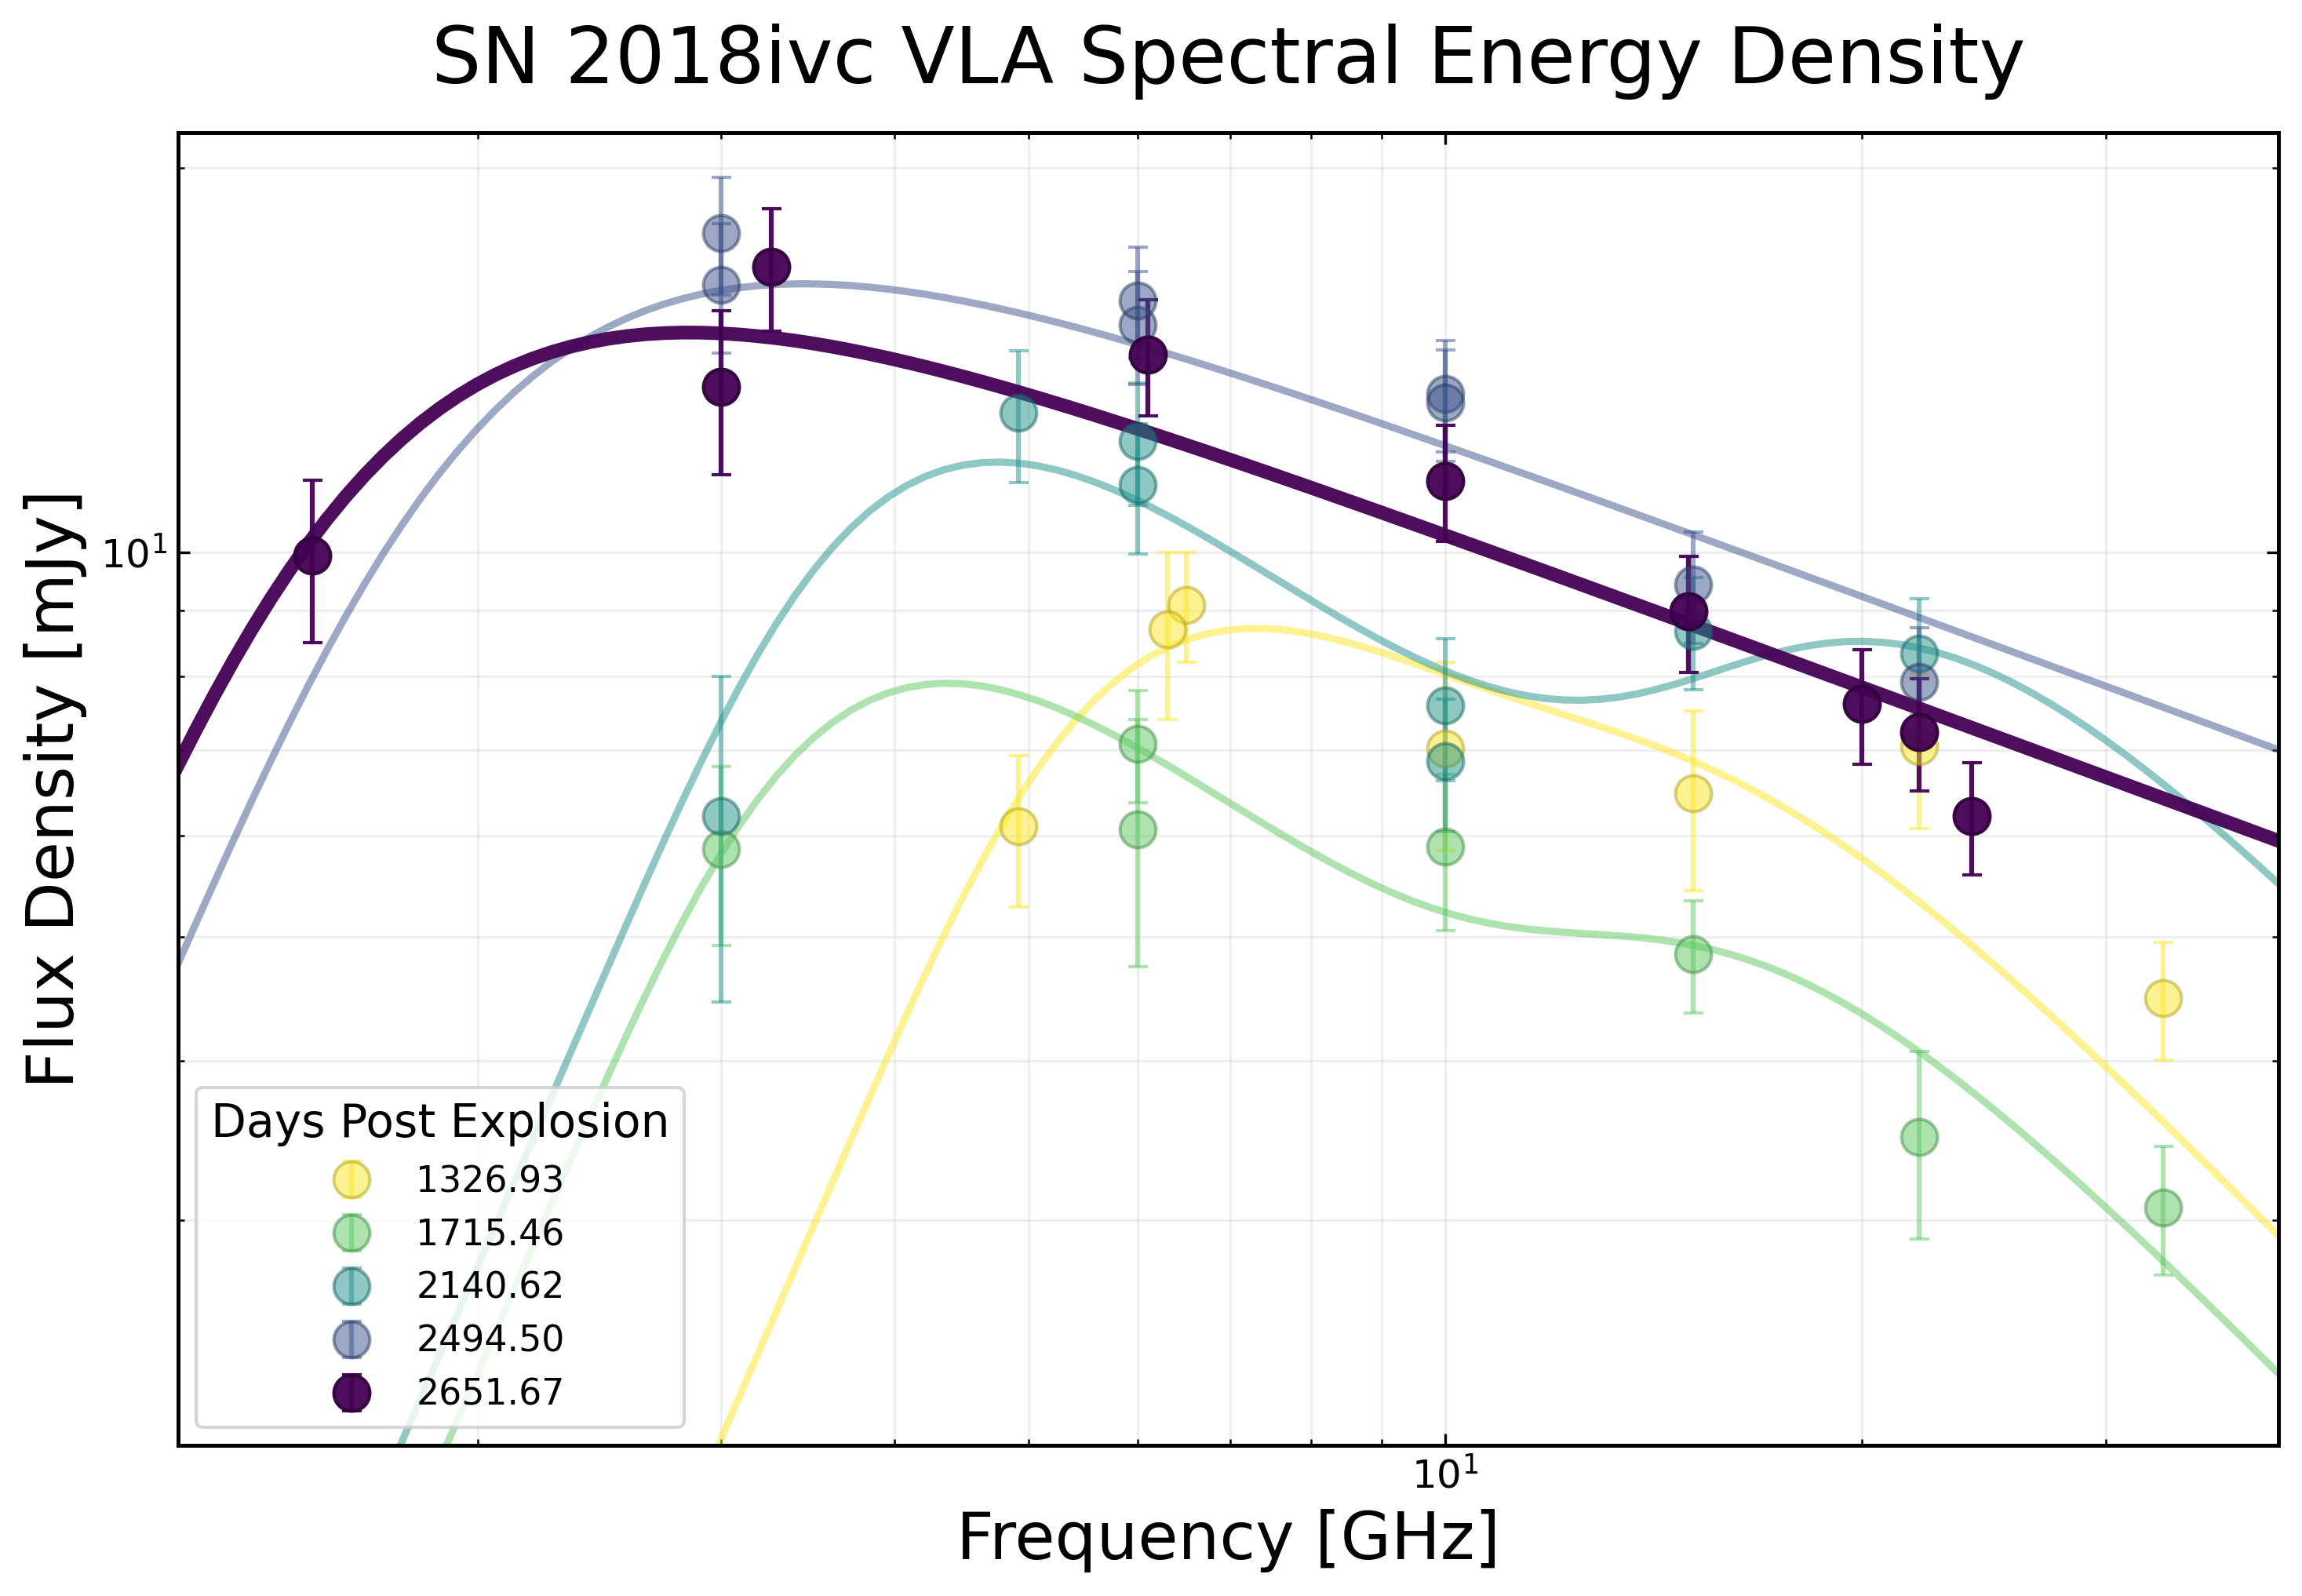

In [8]:
# --- Epoch info: epoch label, phase lower, phase upper, fit file ---
epoch_info = [
    (1300.0, 1200, 1400, "model_params/best_fit_params_1300.0_days.csv"),
    (1700.0, 1600, 1800, "model_params/best_fit_params_1700.0_days.csv"),
    (2100.0, 2000, 2200, "model_params/best_fit_params_2100.0_days.csv"),
    (2500.0, 2350, 2550, "model_params/best_fit_params_2500.0_days.csv"),
    (2650.0, 2550, 2750, "model_params/best_fit_params_2650.0_days.csv"),
]

# VLBA X-band receiver range [GHz]
vlba_x_band = (8.0, 8.8)

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:-1], colors[:-1]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.5,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.5)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[-1:], colors[-1:]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=4.2, alpha=0.95)

# --- VLBA X-band coverage ---
# ax.axvspan(*vlba_x_band, color="grey", alpha=0.25, zorder=0)
# ax.text(x=8.45 , y=10, s="VLBA X band (8.0–8.8 GHz)", fontsize=14, color="black", rotation=90, va="top", ha="center")

# --- VLA band coverage ---
vla_bands = {
    "L": (1.0, 2.0),
    "S": (2.0, 4.0),
    "C": (4.0, 8.0),
    "X": (8.0, 12.0),
    "Ku": (12.0, 18.0),
    "K": (18.0, 26.5),
}

# for band, (lo, hi) in vla_bands.items():
#     ax.axvline(np.mean([lo, hi]), color="red", alpha=0.5, lw=1.5, ls="--", zorder=0)
#     ax.text(x=np.sqrt(lo*hi), y=15, s=f"VLA {band}", fontsize=16, color="red", rotation=90, va="bottom", ha="center")


# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data["freq"]), 1.2*np.max(data["freq"]))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data["flux"]), 1.2*np.max(data["flux"]))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]", fontsize=20)
ax.set_ylabel("Flux Density [mJy]", fontsize=20)
ax.set_title("SN 2018ivc VLA Spectral Energy Density", fontsize=24, pad=15)

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which="both", alpha=0.2)

fig.tight_layout()
fig.savefig("figures/vlba_proposal_sed.png", bbox_inches="tight", dpi=300)
fig.savefig("figures/vlba_proposal_sed.pdf", bbox_inches="tight")

plt.show()


## Figure 2: Late-Time Radio Light Curve with Requested VLBA Observation Phases

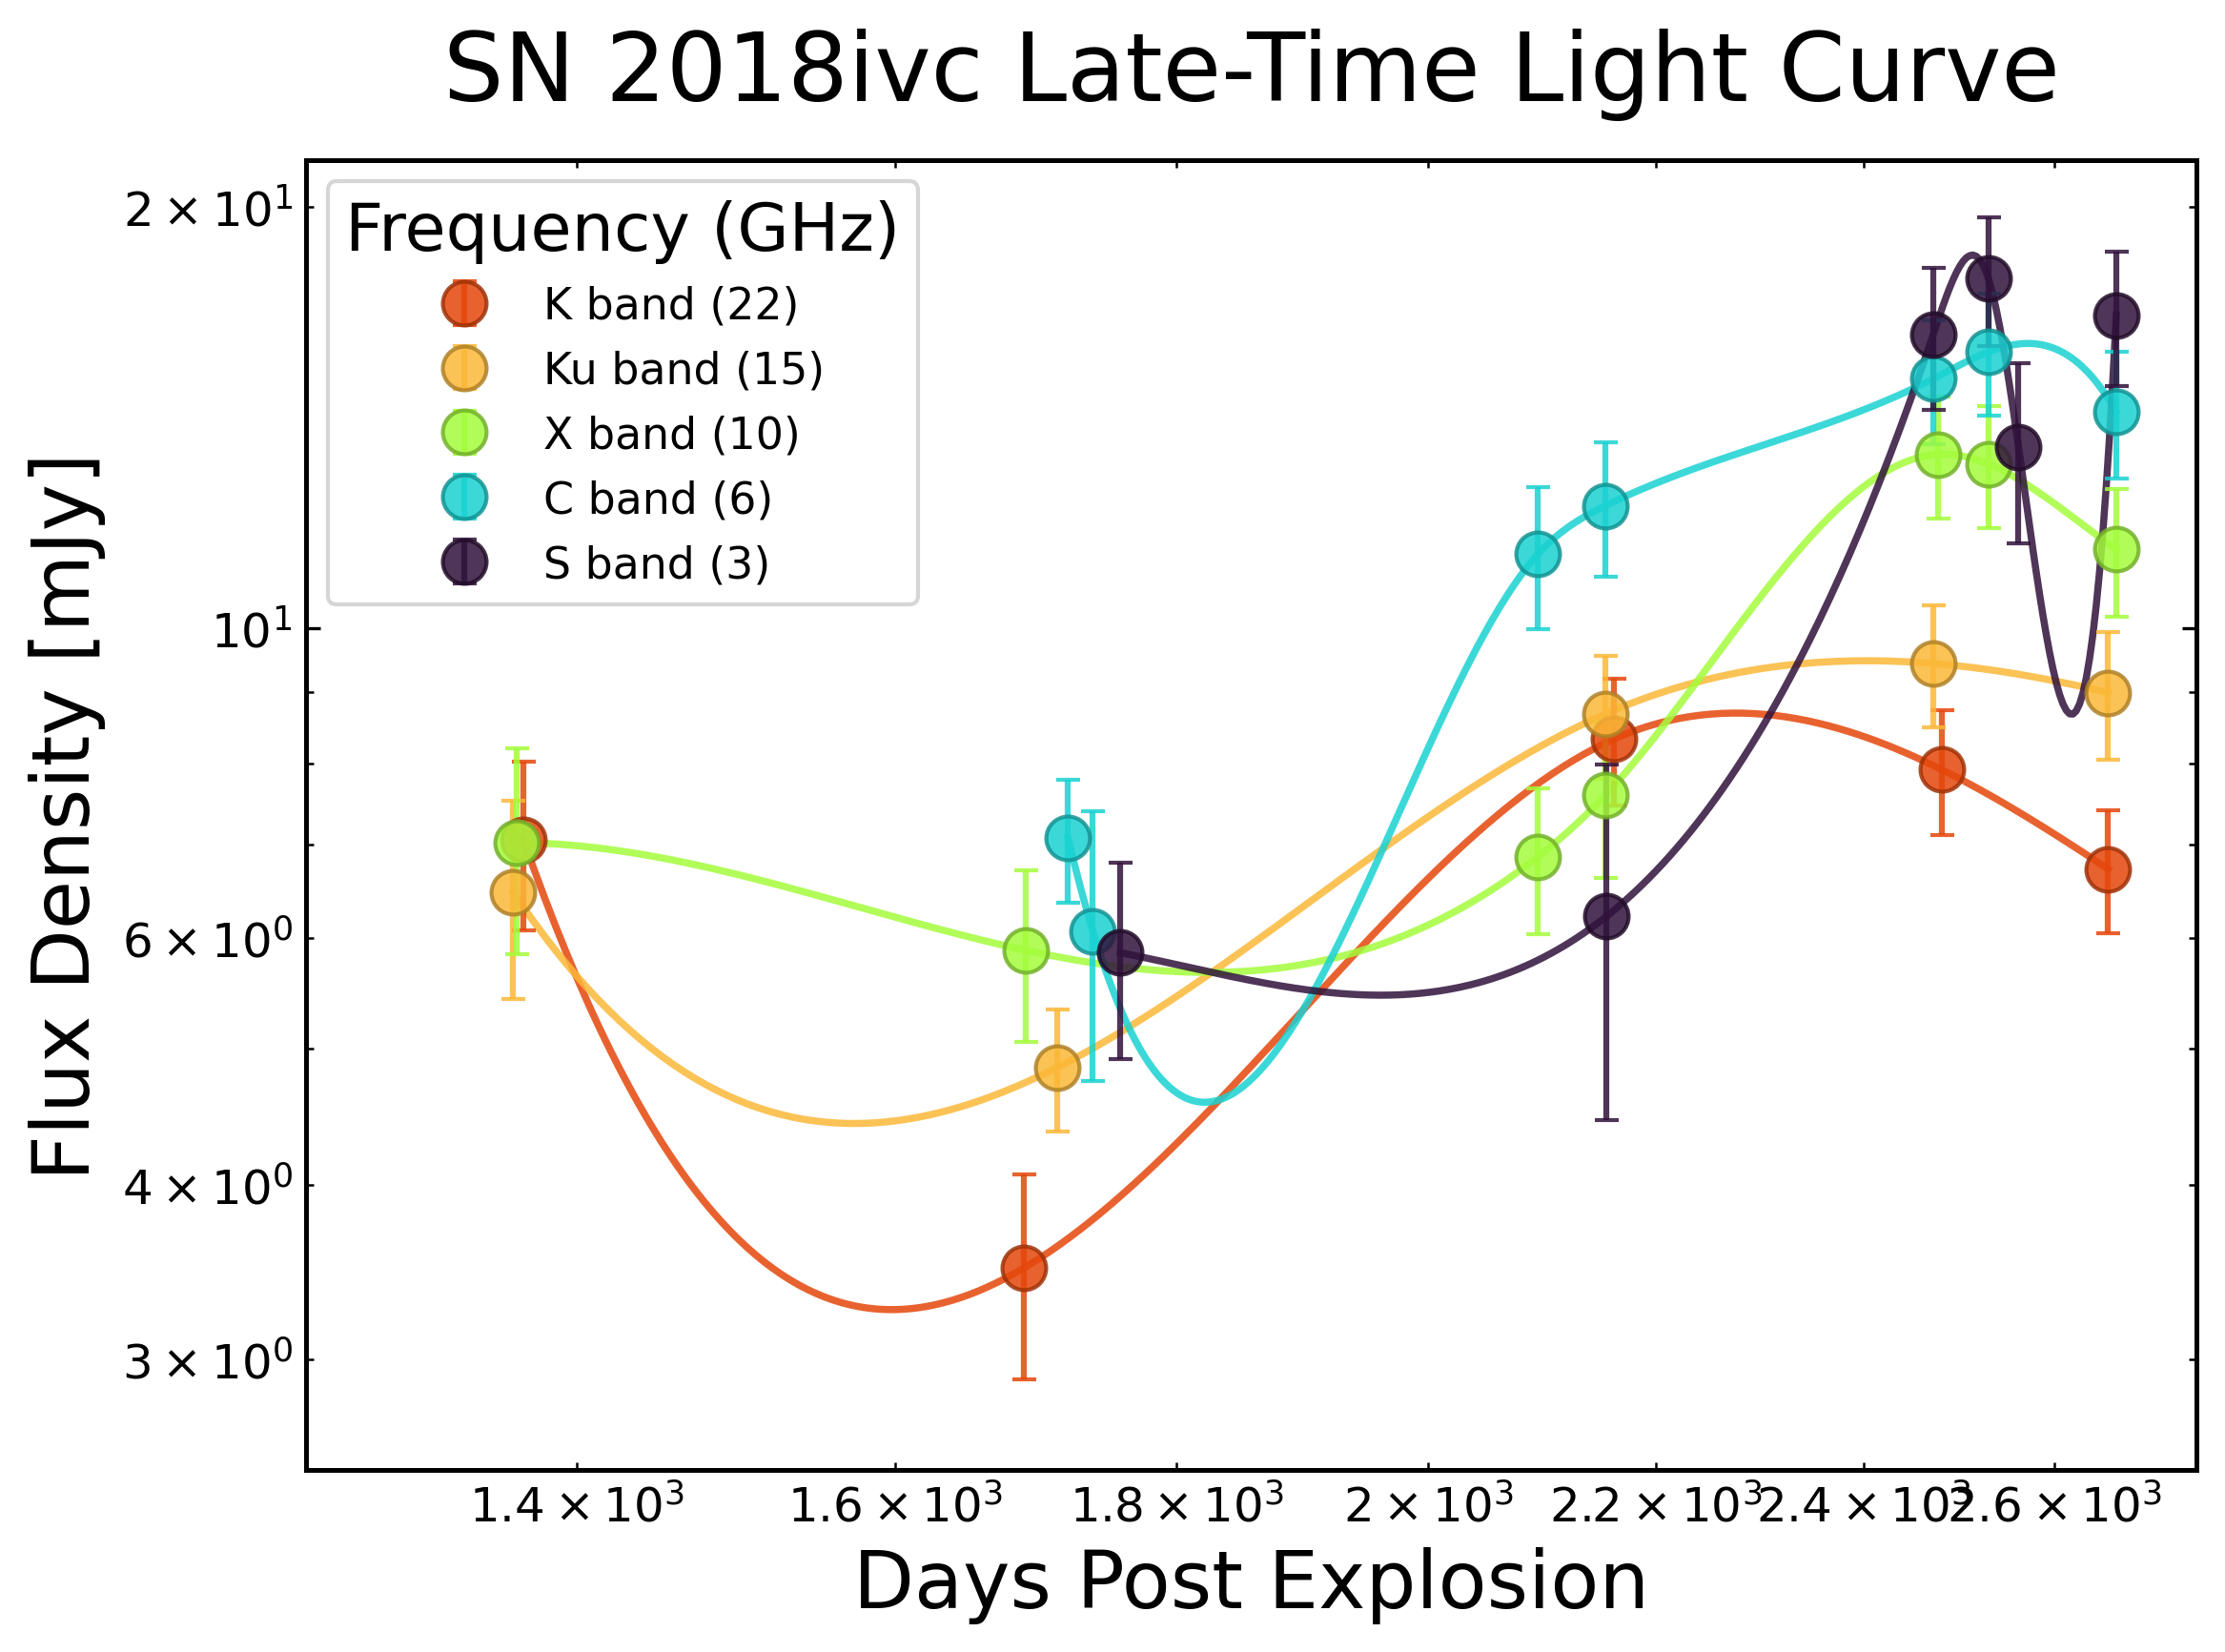

In [9]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from scipy.interpolate import make_interp_spline


# Bin the data by band
data_sorted = data.sort_values("phase")

data_Ku = data_sorted[
    (data_sorted["freq"] > 11.0) & (data_sorted["freq"] < 19.0)
]
data_X = data_sorted[
    (data_sorted["freq"] > 9.0) & (data_sorted["freq"] < 11.0) & (data_sorted["phase"] > 1e3)
]
data_S = data_sorted[
    (data_sorted["freq"] > 2.0) & (data_sorted["freq"] < 4.0)
]
data_Ka = data_sorted[
    (data_sorted["freq"] > 30.0) & (data_sorted["freq"] < 35.0) & (data_sorted["phase"] > 1e3)
]
data_K = data_sorted[
    (data_sorted["freq"] > 20.0) & (data_sorted["freq"] < 25.0) & (data_sorted["phase"] > 1e3)
]
data_C = data_sorted[
    (data_sorted["freq"] > 5.0) & (data_sorted["freq"] < 7.0) & (data_sorted["phase"] > 1.5e3)
]


freq_map = {
    "Ku band (15)": 15,
    "X band (10)": 10,
    "S band (3)": 3,
    "Ka band (33)": 33,
    "K band (22)": 22,
    "C band (6)": 6,
}

freqs = list(freq_map.values())

norm = LogNorm(vmin=min(freqs), vmax=max(freqs))
cmap = mpl.colormaps["turbo"]

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])


# Requested VLBA observation phases [days post explosion]
vlba_phase_1 = 3136
vlba_phase_2 = 3505
vlba_window_halfwidth = 15


fig, ax = plt.subplots(dpi=300, figsize=(8, 6))


def plot_band(band_data, label, n_smooth=300):
    """Plot measured points and a smooth interpolating spline."""

    frequency = freq_map[label]
    color = cmap(norm(frequency))

    # Keep only valid, positive values because the axes are logarithmic
    clean_data = (
        band_data[["phase", "flux", "flux_err"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    clean_data = clean_data[
        (clean_data["phase"] > 0)
        & (clean_data["flux"] > 0)
        & (clean_data["flux_err"] >= 0)
    ].sort_values("phase")

    # make_interp_spline requires unique x values. If several measurements
    # have the same phase, combine them before constructing the spline.
    clean_data = (
        clean_data.groupby("phase", as_index=False)
        .agg(
            flux=("flux", "mean"),
            flux_err=("flux_err", "mean"),
        )
        .sort_values("phase")
    )

    phase = clean_data["phase"].to_numpy()
    flux = clean_data["flux"].to_numpy()
    flux_err = clean_data["flux_err"].to_numpy()

    if len(phase) == 0:
        return

    # Plot the measured data points and uncertainties without straight
    # connecting segments.
    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        phase,
        flux,
        yerr=flux_err,
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        linestyle="none",
        color=color,
        markeredgecolor=edge_color,
        alpha=0.85,
        label=label,
        zorder=3,
    )

    # At least two unique points are needed for interpolation.
    if len(phase) >= 2:
        log_phase = np.log10(phase)
        log_flux = np.log10(flux)

        # Cubic for four or more points; reduce the spline order when fewer
        # measurements are available.
        spline_order = min(3, len(phase) - 1)

        spline = make_interp_spline(
            log_phase,
            log_flux,
            k=spline_order,
        )

        smooth_log_phase = np.linspace(
            log_phase.min(),
            log_phase.max(),
            n_smooth,
        )

        smooth_phase = 10**smooth_log_phase
        smooth_flux = 10 ** spline(smooth_log_phase)

        ax.plot(
            smooth_phase,
            smooth_flux,
            color=color,
            alpha=0.85,
            linewidth=1.8,
            zorder=2,
        )


#plot_band(data_Ka, "Ka band")
plot_band(data_K, "K band (22)")
plot_band(data_Ku, "Ku band (15)")
plot_band(data_X, "X band (10)")
plot_band(data_C, "C band (6)")
plot_band(data_S, "S band (3)")


# # VLBA observation windows
# for phase in (vlba_phase_1, vlba_phase_2):
#     ax.axvspan(
#         phase - 3*vlba_window_halfwidth,
#         phase + 3*vlba_window_halfwidth,
#         color="black",
#         alpha=0.15,
#         zorder=0,
#     )

# ax.text(x=vlba_phase_1, y=5, s="Epoch 1: Semester 27A", fontsize=12, color="black", rotation=90, va="bottom", ha="center")
# ax.text(x=vlba_phase_2, y=5, s="Epoch 2: Semester 28A", fontsize=12, color="black", rotation=90, va="bottom", ha="center")


# Axes formatting
ax.set_xscale("log")
ax.set_yscale("log")

ax.legend(
    title="Frequency (GHz)",
    title_fontsize="large",
)

ax.set_xlabel("Days Post Explosion", fontsize=20)
ax.set_ylabel("Flux Density [mJy]", fontsize=20)
ax.set_title(
    "SN 2018ivc Late-Time Light Curve", fontsize=24, pad=15
)

ax.set_xlim(1250, None)
ax.set_ylim(2.5, None)

# # Logarithmic colorbar
# cbar = fig.colorbar(
#     sm,
#     ax=ax,
#     fraction=0.046,
# )

# cbar.set_label("Frequency (GHz)")

fig.tight_layout()

fig.savefig(
    "figures/vlba_proposal_lightcurve.png",
    bbox_inches="tight",
    dpi=300,
)

fig.savefig(
    "figures/vlba_proposal_lightcurve.pdf",
    bbox_inches="tight",
)

plt.show()